Check the notebook environment

In [5]:
import sys
import os

print("Python executable:")
print(sys.executable)

print("\nCurrent working directory:")
print(os.getcwd())

Python executable:
d:\Projects\CIFAKE-AI-DETECTOR\venv\Scripts\python.exe

Current working directory:
d:\Projects\CIFAKE-AI-DETECTOR\notebooks


Checking Important libraries

In [6]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

print("\nAvailable GPUs:")
print(tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
Pandas: 2.2.3
NumPy: 2.4.6

Available GPUs:
[]


Loading the datasets 

In [7]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SPLITS_DIR = PROJECT_ROOT / "dataset" / "splits"

print("Project root:", PROJECT_ROOT)
print("Splits directory:", SPLITS_DIR)

train_df = pd.read_csv(SPLITS_DIR / "train.csv")
val_df = pd.read_csv(SPLITS_DIR / "validation.csv")
test_df = pd.read_csv(SPLITS_DIR / "test.csv")

print("\nTrain:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

Project root: d:\Projects\CIFAKE-AI-DETECTOR
Splits directory: d:\Projects\CIFAKE-AI-DETECTOR\dataset\splits

Train: 90000
Validation: 10000
Test: 20000
Total: 120000


Train.csv file contains 

In [8]:
train_df.head()

,image_path,label
0,train/FAKE/3775 (2).jpg,1
1,train/REAL/1728 (2).jpg,0
2,train/FAKE/5304 (4).jpg,1
3,train/FAKE/4467 (4).jpg,1
4,train/FAKE/3809 (8).jpg,1


columns in the training dataset we loaded 

In [9]:
print(train_df.columns)

Index(['image_path', 'label'], dtype='object')


datatype of the training dataset

In [10]:
print(train_df.dtypes)

image_path    object
label          int64
dtype: object


*Check REAL vs FAKE distribution*
```
0 = REAL
1 = FAKE
```

In [11]:
print("Training set:")
print(train_df["label"].value_counts())

print("\nValidation set:")
print(val_df["label"].value_counts())

print("\nTest set:")
print(test_df["label"].value_counts())

Training set:
label
1    45000
0    45000
Name: count, dtype: int64

Validation set:
label
1    5000
0    5000
Name: count, dtype: int64

Test set:
label
1    10000
0    10000
Name: count, dtype: int64


In [12]:
label_names = {
    0: "REAL",
    1: "FAKE"
}

train_df["label_name"] = train_df["label"].map(label_names)

print(train_df["label_name"].value_counts())

label_name
FAKE    45000
REAL    45000
Name: count, dtype: int64


*Visualize the class Distribution*

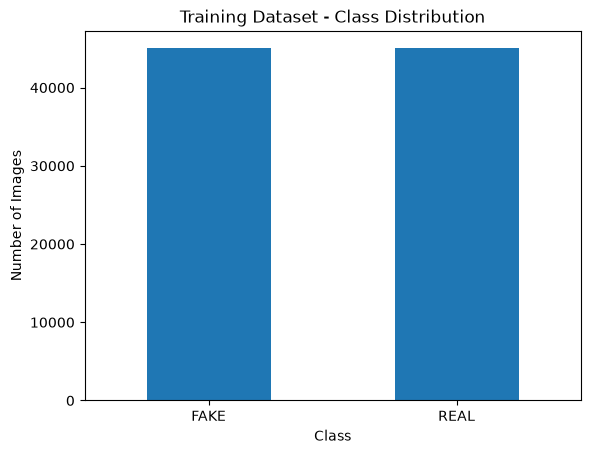

In [13]:
train_df["label_name"].value_counts().plot(kind="bar")

plt.title("Training Dataset - Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.show()

WHere the image actually exists????

In [17]:
DATASET_ROOT = Path(
    r"C:\Users\singu\Downloads\CIFAKE-Real-and-AI-Generated-Synthetic-Images-main\CIFAKE-Real-and-AI-Generated-Synthetic-Images-main\DATASET"
)

print("Dataset root:")
print(DATASET_ROOT)

print("\nExists:", DATASET_ROOT.exists())

Dataset root:
C:\Users\singu\Downloads\CIFAKE-Real-and-AI-Generated-Synthetic-Images-main\CIFAKE-Real-and-AI-Generated-Synthetic-Images-main\DATASET

Exists: True


In [18]:
relative_path = train_df.iloc[0]["image_path"]

actual_image_path = DATASET_ROOT / relative_path

print("Relative path:")
print(relative_path)

print("\nActual image path:")
print(actual_image_path)

print("\nImage exists:", actual_image_path.exists())

Relative path:
train/FAKE/3775 (2).jpg

Actual image path:
C:\Users\singu\Downloads\CIFAKE-Real-and-AI-Generated-Synthetic-Images-main\CIFAKE-Real-and-AI-Generated-Synthetic-Images-main\DATASET\train\FAKE\3775 (2).jpg

Image exists: True


Display one REAL and one FAKE image

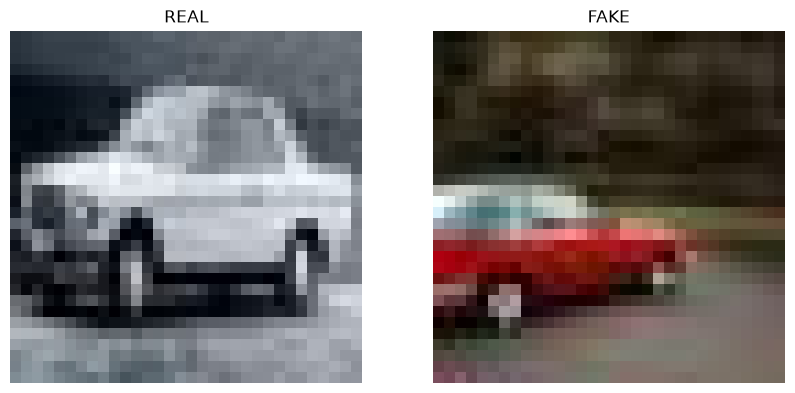

In [19]:
from PIL import Image
import matplotlib.pyplot as plt

# Get one REAL image
real_row = train_df[train_df["label"] == 0].iloc[0]

# Get one FAKE image
fake_row = train_df[train_df["label"] == 1].iloc[0]

# Build the complete paths
real_path = DATASET_ROOT / real_row["image_path"]
fake_path = DATASET_ROOT / fake_row["image_path"]

# Open the images
real_image = Image.open(real_path)
fake_image = Image.open(fake_path)

# Display them
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(real_image)
plt.title("REAL")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(fake_image)
plt.title("FAKE")
plt.axis("off")

plt.show()

In [20]:
print("REAL image:")
print("Size:", real_image.size)
print("Mode:", real_image.mode)

print("\nFAKE image:")
print("Size:", fake_image.size)
print("Mode:", fake_image.mode)

REAL image:
Size: (32, 32)
Mode: RGB

FAKE image:
Size: (32, 32)
Mode: RGB


Look at many images, not just one

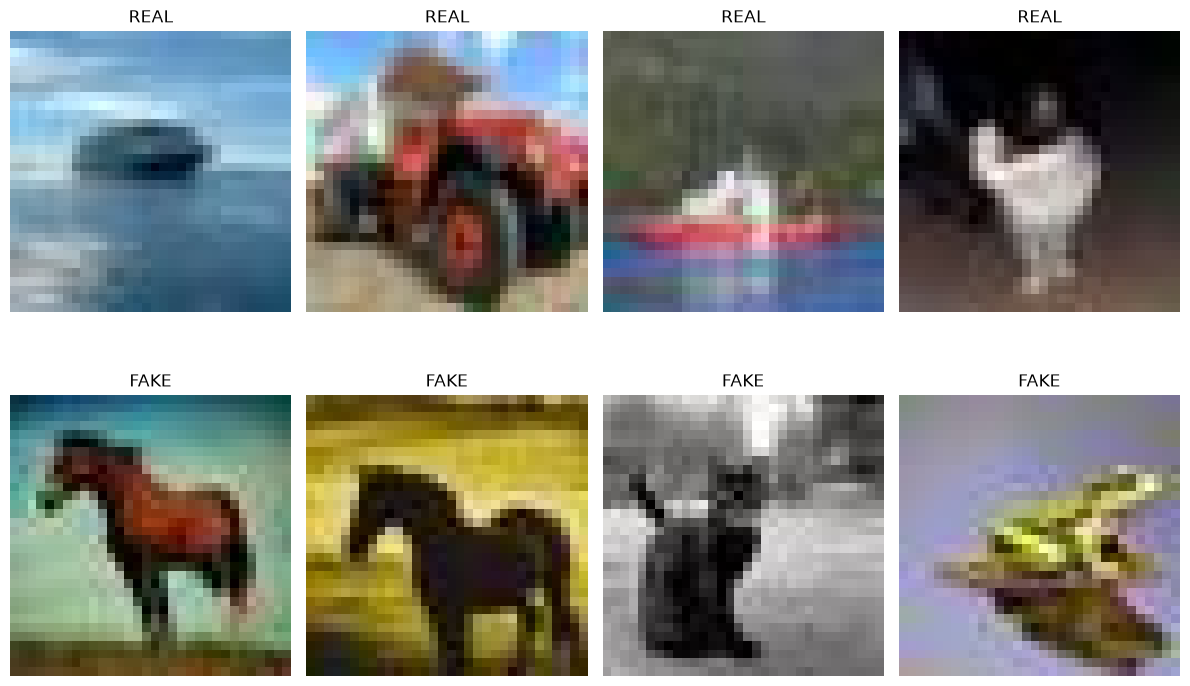

In [28]:
real_samples = train_df[train_df["label"] == 0].sample(4, random_state=42)
fake_samples = train_df[train_df["label"] == 1].sample(4, random_state=42)

samples = pd.concat([real_samples, fake_samples])

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(samples.iterrows()):
    image_path = DATASET_ROOT / row["image_path"]
    image = Image.open(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title("REAL" if row["label"] == 0 else "FAKE")
    plt.axis("off")

plt.tight_layout()
plt.show()

lets inspect the pixel values 

In [29]:
real_array = np.array(real_image)

print("Shape:", real_array.shape)
print("Data type:", real_array.dtype)
print("Minimum pixel value:", real_array.min())
print("Maximum pixel value:", real_array.max())

Shape: (32, 32, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [31]:
image = tf.cast(image, tf.float32) / 255.0
normalized_real = real_array.astype(np.float32) / 255.0

print("Shape:", normalized_real.shape)
print("Data type:", normalized_real.dtype)
print("Minimum:", normalized_real.min())
print("Maximum:", normalized_real.max())

Shape: (32, 32, 3)
Data type: float32
Minimum: 0.0
Maximum: 1.0


In [32]:
real_pixels = []
fake_pixels = []

for _, row in train_df.sample(1000, random_state=42).iterrows():
    image_path = DATASET_ROOT / row["image_path"]
    image = np.array(Image.open(image_path))

    mean_pixel = image.mean()

    if row["label"] == 0:
        real_pixels.append(mean_pixel)
    else:
        fake_pixels.append(mean_pixel)

print("REAL average pixel intensity:",
      np.mean(real_pixels))

print("FAKE average pixel intensity:",
      np.mean(fake_pixels))

REAL average pixel intensity: 120.72310121597782
FAKE average pixel intensity: 109.32873987268518


In [33]:
train_df.sample(1000, random_state=42)

,image_path,label,label_name
89610,train/FAKE/5340 (8).jpg,1,FAKE
12456,train/FAKE/3807 (3).jpg,1,FAKE
53403,train/FAKE/3183 (5).jpg,1,FAKE
62905,train/REAL/3544 (2).jpg,0,REAL
66339,train/REAL/1199 (7).jpg,0,REAL
...,...,...,...
34447,train/REAL/0553 (3).jpg,0,REAL
15654,train/REAL/0765.jpg,0,REAL
11947,train/REAL/1022 (10).jpg,0,REAL
15399,train/REAL/4140 (2).jpg,0,REAL


In [34]:
image.mean()

np.float64(125.79264322916667)